This notebook is a **teaching template** that demonstrates a clean end-to-end PyTorch workflow:

- **Generate** a small RGB image dataset **to disk** (images + `labels.csv`)
- Implement a custom **Dataset** that loads files from disk
- Create **train/val/test** splits with **stratification**
- Build DataLoaders and understand **workers**
- Implement one model that contains:
  - a **residual add** block (with optional **1×1 projection**)
  - a **concat skip** block (with **1×1 compression** after concatenation)
- Train using a small **Trainer** class (loss / optimizer / augmentations injected)
- Evaluate on validation + test and visualize predictions

> The goal here is not to build the “best” model.  
> The goal is to show **how to structure code** and how common building blocks work.


## 1) Setup (imports, device, reproducibility)

We will:
- select `cuda` if available,
- set seeds for reproducibility.

Note: perfect determinism is not always guaranteed on GPU, but this is good practice for teaching and debugging.


In [8]:
import os
import sys
import random
from pathlib import Path
from dataclasses import dataclass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset

from torchvision import transforms as T

from sklearn.model_selection import train_test_split


# ---- Project paths ----
PROJECT_ROOT = Path("quadrant_dots_project").resolve()
DATA_ROOT = PROJECT_ROOT / ".." / ".." / "Datasets" / "quadrant_dots_rgb"

# Make project importable (so we can import our dataset + generator modules)
sys.path.append(str(PROJECT_ROOT))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)


Device: cpu


## 2) Generate the dataset to disk (one-time)

**Important design choice:** we do **not** generate samples inside `__getitem__`.  
Instead we generate a fixed dataset **once** and save:

```
DATA_ROOT/
  images/
    000000.png
    000001.png
    ...
  labels.csv
```

That is closer to how many real projects work (files on disk).

You can safely re-run this cell: it only generates if `labels.csv` does not exist.


In [9]:
DATA_ROOT.mkdir(parents=True, exist_ok=True)

# ----------------------------
# Generator configuration
# ----------------------------

@dataclass
class GeneratorConfig:
    img_size: int = 64
    n_dots: int = 30
    dot_radius: int = 1
    background_noise_std: float = 0.02
    seed: int = 42


# ----------------------------
# Image generation
# ----------------------------

def generate_image(cfg, rng):

    img = np.zeros((cfg.img_size, cfg.img_size, 3), dtype=np.float32)

    quadrant = rng.integers(0, 4)

    if quadrant == 0:
        x_range = (0, cfg.img_size // 2)
        y_range = (0, cfg.img_size // 2)
    elif quadrant == 1:
        x_range = (cfg.img_size // 2, cfg.img_size)
        y_range = (0, cfg.img_size // 2)
    elif quadrant == 2:
        x_range = (0, cfg.img_size // 2)
        y_range = (cfg.img_size // 2, cfg.img_size)
    else:
        x_range = (cfg.img_size // 2, cfg.img_size)
        y_range = (cfg.img_size // 2, cfg.img_size)

    for _ in range(cfg.n_dots):

        x = rng.integers(*x_range)
        y = rng.integers(*y_range)

        color = rng.random(3)

        img[
            y - cfg.dot_radius : y + cfg.dot_radius + 1,
            x - cfg.dot_radius : x + cfg.dot_radius + 1,
        ] = color

    noise = rng.normal(0, cfg.background_noise_std, img.shape)
    img = np.clip(img + noise, 0, 1)

    img = (img * 255).astype(np.uint8)

    return img, quadrant


# ----------------------------
# Dataset generation
# ----------------------------

def generate_dataset(out_dir, n_samples, cfg):

    out_dir = Path(out_dir)
    img_dir = out_dir / "images"

    img_dir.mkdir(parents=True, exist_ok=True)

    rng = np.random.default_rng(cfg.seed)

    records = []

    for i in range(n_samples):

        img, label = generate_image(cfg, rng)

        filename = f"img_{i:05d}.png"

        Image.fromarray(img).save(img_dir / filename)

        records.append(
            {
                "file": filename,
                "label": label,
            }
        )

    df = pd.DataFrame(records)

    csv_path = out_dir / "labels.csv"

    df.to_csv(csv_path, index=False)

    return csv_path


# ----------------------------
# Run generation
# ----------------------------

labels_csv = DATA_ROOT / "labels.csv"

if not labels_csv.exists():

    cfg = GeneratorConfig(
        img_size=64,
        n_dots=30,
        dot_radius=1,
        background_noise_std=0.02,
        seed=42,
    )

    csv_path = generate_dataset(out_dir=str(DATA_ROOT), n_samples=800, cfg=cfg)

    print("Generated:", csv_path)

else:
    print("Dataset already exists:", labels_csv)

Dataset already exists: C:\Users\jom_j\Documents\Master\Courses\IN4310\Coursework\Week_04\quadrant_dots_project\..\..\Datasets\quadrant_dots_rgb\labels.csv


## 3) Inspect the dataset quickly

We will:
- load `labels.csv`,
- check class balance,
- visualize a few sample images from disk.


,file,label
0,img_00000.png,0
1,img_00001.png,2
2,img_00002.png,2
3,img_00003.png,1
4,img_00004.png,0


Class counts:
label
0    208
1    182
2    227
3    183
Name: count, dtype: int64


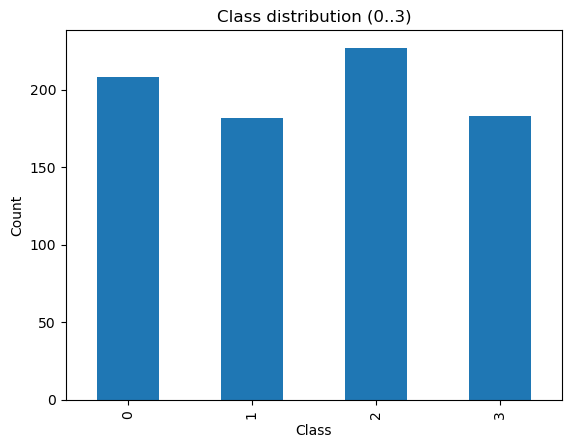

In [10]:
df = pd.read_csv(DATA_ROOT / "labels.csv")
display(df.head())

class_counts = df["label"].value_counts().sort_index()
print("Class counts:")
print(class_counts)

plt.figure()
class_counts.plot(kind="bar")
plt.title("Class distribution (0..3)")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()


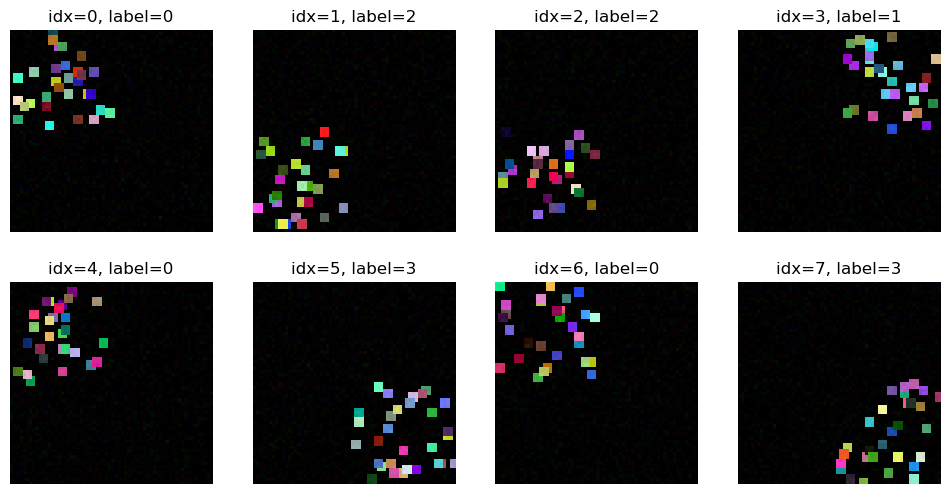

In [11]:
from PIL import Image

def show_samples(data_root: Path, indices, ncols: int = 4):
    n = len(indices)
    nrows = int(np.ceil(n / ncols))
    plt.figure(figsize=(3*ncols, 3*nrows))
    for i, idx in enumerate(indices):
        row = df.iloc[idx]
        img_path = data_root / "images" / row["file"]
        img = Image.open(img_path).convert("RGB")
        plt.subplot(nrows, ncols, i+1)
        plt.imshow(img)
        plt.title(f"idx={idx}, label={row['label']}")
        plt.axis("off")
    plt.show()

show_samples(DATA_ROOT, indices=list(range(8)), ncols=4)


## 4) Train/Validation/Test split (stratified)

We want:
- Train: 70%
- Val: 15%
- Test: 15%

We use **stratification** to preserve class proportions across splits.

A good teaching practice is to verify:
- sizes
- no overlap
- class distribution per split


In [13]:
labels = df["label"].to_numpy()
indices = np.arange(len(df))

train_idx, temp_idx = train_test_split(
    indices,
    test_size=0.30,
    random_state=42,
    stratify=labels,
)

temp_labels = labels[temp_idx]
val_idx, test_idx = train_test_split(
    temp_idx,
    test_size=0.50,
    random_state=42,
    stratify=temp_labels,
)

print("Split sizes:")
print("  train:", len(train_idx))
print("  val:  ", len(val_idx))
print("  test: ", len(test_idx))

# Verify disjointness
assert len(set(train_idx) & set(val_idx)) == 0
assert len(set(train_idx) & set(test_idx)) == 0
assert len(set(val_idx) & set(test_idx)) == 0
print("✅ Splits are disjoint.")

def split_hist(name, idx):
    c = pd.Series(labels[idx]).value_counts().sort_index()
    print(f"{name} distribution:\n{c}\n")
    return c

train_counts = split_hist("train", train_idx)
val_counts   = split_hist("val", val_idx)
test_counts  = split_hist("test", test_idx)


Split sizes:
  train: 560
  val:   120
  test:  120
✅ Splits are disjoint.
train distribution:
0    146
1    127
2    159
3    128
Name: count, dtype: int64

val distribution:
0    31
1    27
2    34
3    28
Name: count, dtype: int64

test distribution:
0    31
1    28
2    34
3    27
Name: count, dtype: int64



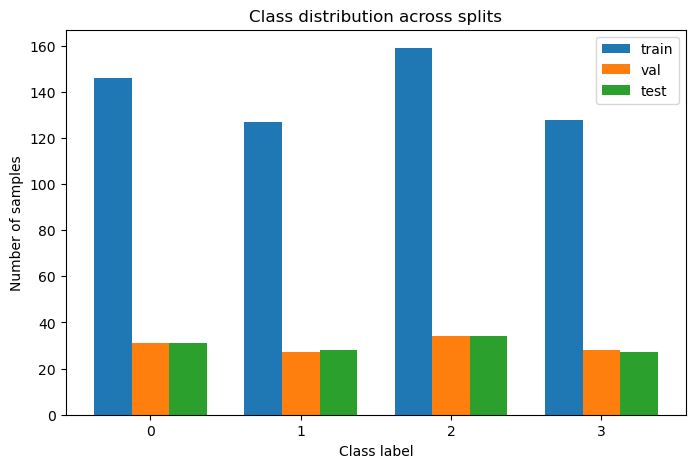

In [14]:
fig, ax = plt.subplots(figsize=(8,5))
classes = sorted(df["label"].unique())
x = np.arange(len(classes))
width = 0.25

ax.bar(x - width, train_counts.values, width, label="train")
ax.bar(x, val_counts.values, width, label="val")
ax.bar(x + width, test_counts.values, width, label="test")

ax.set_xticks(x)
ax.set_xticklabels(classes)

ax.set_xlabel("Class label")
ax.set_ylabel("Number of samples")
ax.set_title("Class distribution across splits")

ax.legend()

plt.show()

## 5) Transforms (augmentation) and where they “live”

**Typical PyTorch pattern**
- transforms are attached to the **Dataset** (so every sample is transformed consistently).

**What we do in this notebook**
- For clarity, we define:
  - `base_transform` (used for validation/test)
  - `train_transform` (includes augmentation)
- We will also demonstrate a Trainer design where an augmentation function can be **injected into the Trainer** (similar to loss/optimizer),
  so augmentations are applied **only** during training.

This is not the only design, but it is a useful teaching pattern:
- loss / optimizer / augmentation policy are all “training configuration”.


In [15]:
# NOTE: We avoid flips because they would change the label (quadrant).
# That is an important teaching point: augmentation must preserve the label.

base_transform = T.Compose([
    T.ToTensor(),  # [0,1], shape [C,H,W]
])

train_transform = T.Compose([
    T.RandomAffine(degrees=10, translate=(0.05, 0.05)),
    T.GaussianBlur(kernel_size=3),
    T.ToTensor(),
])


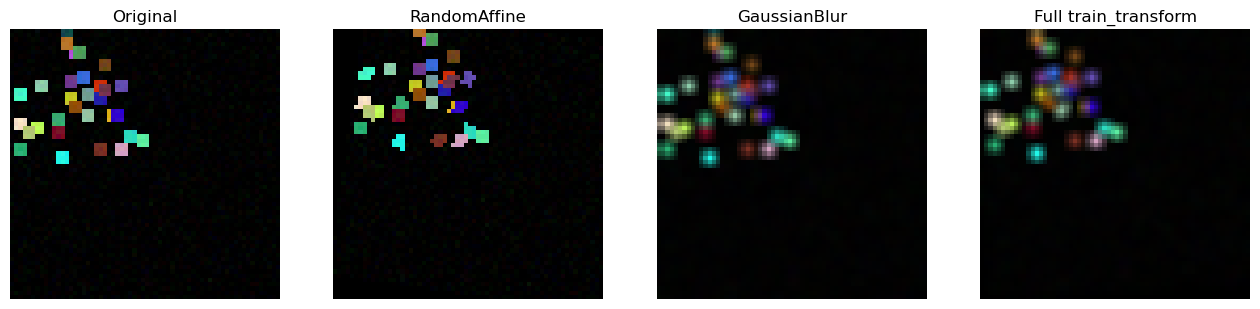

In [16]:
sample_idx = 0

row = df.iloc[sample_idx]
img_path = DATA_ROOT / "images" / row["file"]
img = Image.open(img_path).convert("RGB")

# individual transforms
affine = T.RandomAffine(degrees=10, translate=(0.05, 0.05))
blur = T.GaussianBlur(kernel_size=3)

img_affine = affine(img)
img_blur = blur(img)
img_train = train_transform(img)

fig, axes = plt.subplots(1, 4, figsize=(16,4))

axes[0].imshow(img)
axes[0].set_title("Original")

axes[1].imshow(img_affine)
axes[1].set_title("RandomAffine")

axes[2].imshow(img_blur)
axes[2].set_title("GaussianBlur")

axes[3].imshow(img_train.permute(1,2,0))
axes[3].set_title("Full train_transform")

for ax in axes:
    ax.axis("off")

plt.show()

## 6) Dataset class (loads from disk)

Our custom Dataset lives in a separate file:

- `quadrant_dots_project/datasets/quadrant_dots_dataset.py`

It reads:
- `labels.csv` → filenames + labels
- loads images from `images/`
- applies a transform (passed from the notebook)


In [17]:
from pathlib import Path
import pandas as pd
from PIL import Image
import torch
from torch.utils.data import Dataset

class QuadrantDotsDiskDataset(Dataset):
    """
    A simple disk-backed dataset.

    Folder structure expected:
        root_dir/
            labels.csv           (columns: file,label)
            images/
                img_00000.png
                img_00001.png
                ...

    Returns:
        (image_tensor, label_tensor)
    """

    
    def __init__(self, root_dir: str, transform=None, csv_name: str = "labels.csv"):
        """
        Args:
            root_dir: Path to dataset root folder.
            transform: A torchvision transform applied to the PIL image.
            csv_name: Name of the CSV file with labels.
        """
        self.root_dir = Path(root_dir)
        self.img_dir = self.root_dir / "images"
        self.csv_path = self.root_dir / csv_name
        self.transform = transform

        if not self.csv_path.exists():
            raise FileNotFoundError(f"labels CSV not found: {self.csv_path}")

        if not self.img_dir.exists():
            raise FileNotFoundError(f"images folder not found: {self.img_dir}")

        self.df = pd.read_csv(self.csv_path)

        # Accept either "file" or "filename" column name (more robust for teaching notebooks)
        if "file" in self.df.columns:
            self.file_col = "file"
        elif "filename" in self.df.columns:
            self.file_col = "filename"
        else:
            raise ValueError(
                f"CSV must contain a 'file' or 'filename' column. Found columns: {list(self.df.columns)}"
            )

        if "label" not in self.df.columns:
            raise ValueError(
                f"CSV must contain a 'label' column. Found columns: {list(self.df.columns)}"
            )

    def __len__(self) -> int:
        return len(self.df)

    def __getitem__(self, idx: int):
        """
        Steps:
        1) Read file name + label from the CSV
        2) Load the image from disk
        3) Apply transforms (if provided)
        4) Return tensors (x, y)
        """
        row = self.df.iloc[idx]
        filename = row[self.file_col]
        label = int(row["label"])

        img_path = self.img_dir / filename
        image = Image.open(img_path).convert("RGB")  # keep RGB for our model

        if self.transform is not None:
            image = self.transform(image)

        # CrossEntropyLoss expects class indices as torch.long
        label = torch.tensor(label, dtype=torch.long)

        return image, label

In [18]:
full_dataset = QuadrantDotsDiskDataset(root_dir=str(DATA_ROOT), transform=base_transform)

train_dataset = Subset(QuadrantDotsDiskDataset(root_dir=str(DATA_ROOT), transform=train_transform), train_idx)
val_dataset   = Subset(QuadrantDotsDiskDataset(root_dir=str(DATA_ROOT), transform=base_transform), val_idx)
test_dataset  = Subset(QuadrantDotsDiskDataset(root_dir=str(DATA_ROOT), transform=base_transform), test_idx)

print("Example tensor shape:", train_dataset[0][0].shape, "label:", train_dataset[0][1].item())


Example tensor shape: torch.Size([3, 64, 64]) label: 0


## 7) DataLoaders and workers

Key DataLoader parameters:
- `batch_size`: number of samples per batch
- `shuffle`: randomize sample order (usually **True** for training)
- `num_workers`: number of background worker processes for data loading
- `pin_memory`: often helpful when training on GPU (faster host→device transfer)
- `persistent_workers`: keeps workers alive between epochs (if `num_workers > 0`)

### What are “workers”?
When `num_workers > 0`, PyTorch spawns worker processes that prepare batches in parallel.
While the GPU is busy computing gradients, CPU workers can:
- load images
- decode PNG/JPEG
- apply transforms

This often improves throughput.

**Rule of thumb:** start with `num_workers=0` (simple, debug-friendly), then increase.


In [24]:
batch_size = 64

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0,
    pin_memory=True,
    persistent_workers=False,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0,
    pin_memory=True,
    persistent_workers=False,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0,
    pin_memory=True,
    persistent_workers=False,
)

images, labels_batch = next(iter(train_loader))
print("Batch images:", images.shape)   # [B, C, H, W]
print("Batch labels:", labels_batch.shape)


Batch images: torch.Size([64, 3, 64, 64])
Batch labels: torch.Size([64])


## 8) 1×1 Convolution: examples with shapes

A **1×1 convolution** is a convolution whose kernel is `1×1`.
It does **not** look at neighbors in space — it only mixes **channels** at each pixel.

Common uses:
1) **Channel mixing**: change channels `C_in → C_out` without changing `H×W`
2) **Projection** in residual add: match channels (and sometimes stride)
3) **Compression** after concatenation: concat increases channels, then 1×1 reduces them

Let's print shapes before/after.


In [25]:
# Example A: channel mixing only
x = torch.randn(8, 3, 64, 64)  # [B, C, H, W]
conv1x1 = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=1)

y = conv1x1(x)

print("Example A: channel mixing")
print("  input :", tuple(x.shape))
print("  output:", tuple(y.shape))

# Example B: projection for residual add (match channels)
x = torch.randn(8, 16, 32, 32)
F_x = torch.randn(8, 32, 32, 32)  # main path output has 32 channels

proj = nn.Conv2d(16, 32, kernel_size=1)  # make skip path 16→32
skip = proj(x)
out = F_x + skip

print("\nExample B: residual projection with 1×1")
print("  skip input :", tuple(x.shape))
print("  skip output:", tuple(skip.shape))
print("  main output:", tuple(F_x.shape))
print("  add output :", tuple(out.shape))

# Example C: compression after concatenation
x = torch.randn(8, 16, 32, 32)
F_x = torch.randn(8, 16, 32, 32)

cat = torch.cat([F_x, x], dim=1)  # channels: 16+16=32
compress = nn.Conv2d(32, 16, kernel_size=1)
z = compress(cat)

print("\nExample C: concat + 1×1 compression")
print("  x shape     :", tuple(x.shape))
print("  F(x) shape  :", tuple(F_x.shape))
print("  concat shape:", tuple(cat.shape))
print("  compressed  :", tuple(z.shape))


Example A: channel mixing
  input : (8, 3, 64, 64)
  output: (8, 16, 64, 64)

Example B: residual projection with 1×1
  skip input : (8, 16, 32, 32)
  skip output: (8, 32, 32, 32)
  main output: (8, 32, 32, 32)
  add output : (8, 32, 32, 32)

Example C: concat + 1×1 compression
  x shape     : (8, 16, 32, 32)
  F(x) shape  : (8, 16, 32, 32)
  concat shape: (8, 32, 32, 32)
  compressed  : (8, 16, 32, 32)


## 9) Model: one residual-add block, then one concat-skip block

We implement **one model** that includes both patterns in sequence:

1) **Residual Add Block**
   - output = F(x) + x
   - if shapes do not match, use **1×1 projection** for the skip path

2) **Residual Concat Block**
   - output = concat(F(x), x) along channel dimension
   - then a **1×1 convolution** compresses channels back down (optional but common)

This “Frankenstein” model is intentionally built for demonstration.


In [26]:
class ConvBNAct(nn.Module):
    def __init__(self, in_ch: int, out_ch: int, kernel_size: int = 3, stride: int = 1, padding: int = 1):
        super().__init__()
        self.conv = nn.Conv2d(in_ch, out_ch, kernel_size=kernel_size, stride=stride, padding=padding, bias=False)
        self.bn = nn.BatchNorm2d(out_ch)
        self.act = nn.ReLU(inplace=True)

    def forward(self, x):
        return self.act(self.bn(self.conv(x)))


class ResidualAddBlock(nn.Module):
    """y = F(x) + skip(x). Uses 1×1 projection if needed."""
    def __init__(self, in_ch: int, out_ch: int, stride: int = 1):
        super().__init__()
        self.main = nn.Sequential(
            ConvBNAct(in_ch, out_ch, 3, stride=stride, padding=1),
            nn.Conv2d(out_ch, out_ch, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
        )
        self.proj = None
        if in_ch != out_ch or stride != 1:
            self.proj = nn.Sequential(
                nn.Conv2d(in_ch, out_ch, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_ch),
            )
        self.act = nn.ReLU(inplace=True)

    def forward(self, x):
        out = self.main(x)
        skip = x if self.proj is None else self.proj(x)
        return self.act(out + skip)


class ResidualConcatBlock(nn.Module):
    """y = concat(F(x), skip(x)) then (optionally) compress with 1×1 conv."""
    def __init__(self, in_ch: int, out_ch: int, stride: int = 1, compress_to: int = None):
        super().__init__()
        self.main = nn.Sequential(
            ConvBNAct(in_ch, out_ch, 3, stride=stride, padding=1),
            ConvBNAct(out_ch, out_ch, 3, stride=1, padding=1),
        )

        # To concat, spatial sizes must match. If stride!=1, we downsample skip too.
        self.skip_down = None
        if stride != 1:
            self.skip_down = nn.Conv2d(in_ch, in_ch, kernel_size=1, stride=stride, bias=False)

        # After concat channels become out_ch + in_ch (or out_ch + in_ch if downsample keeps channels)
        cat_ch = out_ch + in_ch
        if compress_to is None:
            compress_to = out_ch  # common: compress back to out_ch
        self.compress = nn.Conv2d(cat_ch, compress_to, kernel_size=1)

    def forward(self, x):
        fx = self.main(x)
        skip = x if self.skip_down is None else self.skip_down(x)
        cat = torch.cat([fx, skip], dim=1)
        return F.relu(self.compress(cat), inplace=True)


class FrankenNet(nn.Module):
    def __init__(self, num_classes: int = 4):
        super().__init__()
        self.stem = nn.Sequential(
            ConvBNAct(3, 16, 3, stride=1, padding=1),
            nn.MaxPool2d(kernel_size=2),  # 64→32
        )

        # Block 1: residual add (shows 1×1 projection if we change channels)
        self.block1 = ResidualAddBlock(in_ch=16, out_ch=32, stride=1)

        # Block 2: concat skip + 1×1 compression
        self.block2 = ResidualConcatBlock(in_ch=32, out_ch=32, stride=2, compress_to=64)  # 32→16 spatial, channels→64

        self.head = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(64, num_classes),
        )

    def forward(self, x):
        x = self.stem(x)
        x = self.block1(x)
        x = self.block2(x)
        return self.head(x)


model = FrankenNet(num_classes=4).to(device)
# Quick shape check
with torch.no_grad():
    dummy = torch.randn(4, 3, 64, 64).to(device)
    out = model(dummy)
print("Output shape:", tuple(out.shape))


Output shape: (4, 4)


## 10) Trainer (loss, optimizer, and augmentation injected)

You asked whether augmentations can be injected into the Trainer similarly to:
- loss function
- optimizer

Yes — as a **teaching pattern**, it can be useful.

In this design:
- The Dataset does basic transforms (e.g., `ToTensor`)
- The Trainer optionally applies an `augment_fn(images)` **only during training**

This keeps training configuration in one place:
- `criterion`
- `optimizer`
- `augment_fn`


In [27]:
from dataclasses import dataclass
from typing import Callable, Dict, Optional, Tuple

@dataclass
class EpochStats:
    loss: float
    acc: float


class Trainer:
    def __init__(
        self,
        model: nn.Module,
        criterion: nn.Module,
        optimizer: torch.optim.Optimizer,
        device: torch.device,
        augment_fn: Optional[Callable[[torch.Tensor], torch.Tensor]] = None,
    ):
        self.model = model
        self.criterion = criterion
        self.optimizer = optimizer
        self.device = device
        self.augment_fn = augment_fn

        self.history: Dict[str, list] = {
            "train_loss": [],
            "train_acc": [],
            "val_loss": [],
            "val_acc": [],
        }

    @staticmethod
    def _accuracy(logits: torch.Tensor, targets: torch.Tensor) -> float:
        preds = logits.argmax(dim=1)
        return (preds == targets).float().mean().item()

    def train_one_epoch(self, loader: DataLoader) -> EpochStats:
        self.model.train()

        total_loss = 0.0
        total_acc = 0.0
        n_batches = 0

        for images, targets in loader:
            images = images.to(self.device, non_blocking=True)
            targets = targets.to(self.device, non_blocking=True)

            # Apply augmentation policy only during training (optional)
            if self.augment_fn is not None:
                images = self.augment_fn(images)

            logits = self.model(images)
            loss = self.criterion(logits, targets)

            self.optimizer.zero_grad(set_to_none=True)
            loss.backward()
            self.optimizer.step()

            total_loss += loss.item()
            total_acc += self._accuracy(logits, targets)
            n_batches += 1

        return EpochStats(loss=total_loss / n_batches, acc=total_acc / n_batches)

    @torch.no_grad()
    def evaluate(self, loader: DataLoader) -> EpochStats:
        self.model.eval()

        total_loss = 0.0
        total_acc = 0.0
        n_batches = 0

        for images, targets in loader:
            images = images.to(self.device, non_blocking=True)
            targets = targets.to(self.device, non_blocking=True)

            logits = self.model(images)
            loss = self.criterion(logits, targets)

            total_loss += loss.item()
            total_acc += self._accuracy(logits, targets)
            n_batches += 1

        return EpochStats(loss=total_loss / n_batches, acc=total_acc / n_batches)

    def fit(self, train_loader: DataLoader, val_loader: DataLoader, epochs: int = 10):
        for epoch in range(1, epochs + 1):
            train_stats = self.train_one_epoch(train_loader)
            val_stats = self.evaluate(val_loader)

            self.history["train_loss"].append(train_stats.loss)
            self.history["train_acc"].append(train_stats.acc)
            self.history["val_loss"].append(val_stats.loss)
            self.history["val_acc"].append(val_stats.acc)

            print(
                f"Epoch {epoch:02d} | "
                f"train loss {train_stats.loss:.4f}, acc {train_stats.acc:.3f} | "
                f"val loss {val_stats.loss:.4f}, acc {val_stats.acc:.3f}"
            )


### A simple augmentation function injected into the Trainer (optional)

To keep the example minimal, we will use a *tensor-level* augmentation:
- add small Gaussian noise

This runs on the same device as the batch (CPU or GPU).

In real projects, many augmentations are easier to do in the Dataset using `torchvision.transforms`,
but demonstrating Trainer-injected augmentation is useful for understanding “configuration injection”.


In [28]:
def batch_noise_augment(images: torch.Tensor, std: float = 0.03) -> torch.Tensor:
    noise = torch.randn_like(images) * std
    return torch.clamp(images + noise, 0.0, 1.0)


## 11) Train

We will:
- define loss + optimizer
- create a Trainer with an augmentation policy
- train for a small number of epochs (this dataset is intentionally easy)


In [29]:
model = FrankenNet(num_classes=4).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

trainer = Trainer(
    model=model,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    augment_fn=lambda x: batch_noise_augment(x, std=0.02),
)

trainer.fit(train_loader, val_loader, epochs=8)


Epoch 01 | train loss 1.3837, acc 0.278 | val loss 1.3862, acc 0.282
Epoch 02 | train loss 1.3555, acc 0.319 | val loss 1.3807, acc 0.282
Epoch 03 | train loss 1.3069, acc 0.512 | val loss 1.3414, acc 0.282
Epoch 04 | train loss 1.2209, acc 0.557 | val loss 1.2218, acc 0.567
Epoch 05 | train loss 1.0919, acc 0.759 | val loss 1.0524, acc 0.541
Epoch 06 | train loss 0.9204, acc 0.775 | val loss 0.8488, acc 0.769
Epoch 07 | train loss 0.7335, acc 0.774 | val loss 0.6449, acc 0.992
Epoch 08 | train loss 0.5550, acc 0.977 | val loss 0.5562, acc 0.992


## 12) Plot training curves

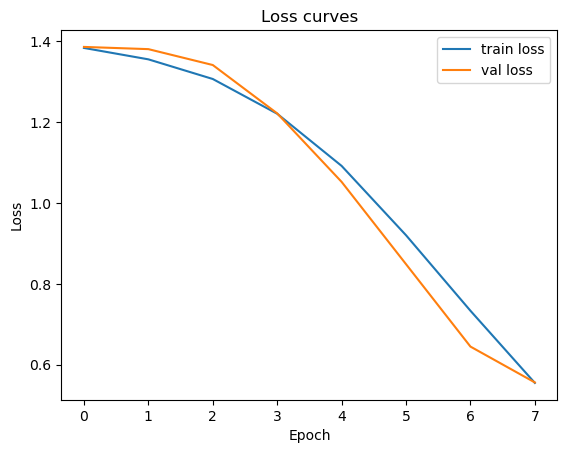

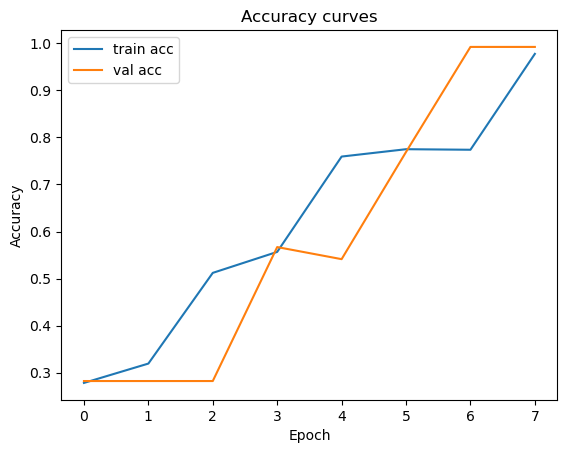

In [30]:
history = trainer.history

plt.figure()
plt.plot(history["train_loss"], label="train loss")
plt.plot(history["val_loss"], label="val loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Loss curves")
plt.show()

plt.figure()
plt.plot(history["train_acc"], label="train acc")
plt.plot(history["val_acc"], label="val acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Accuracy curves")
plt.show()


## 13) Final evaluation on the test set

The test set is evaluated **after** training is complete.


In [31]:
test_stats = trainer.evaluate(test_loader)
print(f"Test loss: {test_stats.loss:.4f}, Test acc: {test_stats.acc:.3f}")


Test loss: 0.5468, Test acc: 1.000


## 14) Visualize a few predictions

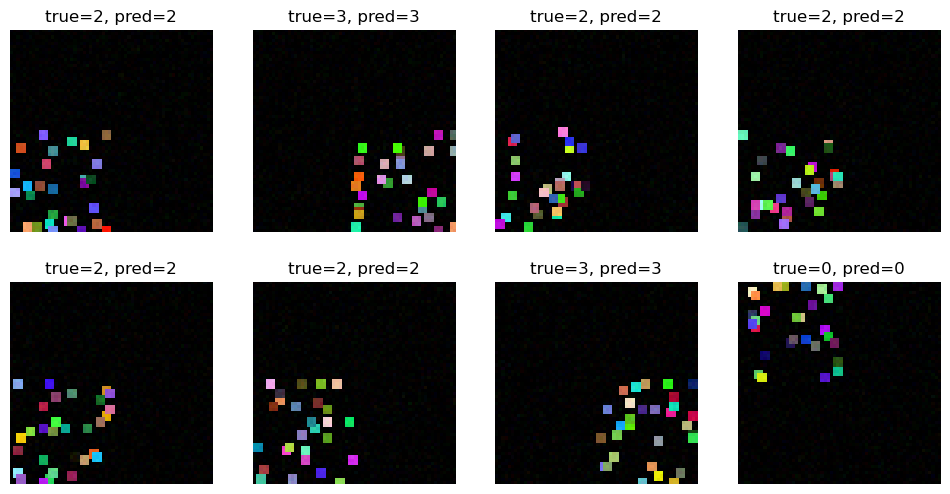

In [32]:
@torch.no_grad()
def show_predictions(model: nn.Module, data_root: Path, dataset: QuadrantDotsDiskDataset, indices, ncols: int = 4):
    model.eval()
    n = len(indices)
    nrows = int(np.ceil(n / ncols))
    plt.figure(figsize=(3*ncols, 3*nrows))

    for i, idx in enumerate(indices):
        # Load original PIL image for visualization (not augmented)
        row = df.iloc[idx]
        img_path = data_root / "images" / row["file"]
        pil = Image.open(img_path).convert("RGB")

        # Model input uses base_transform
        x = base_transform(pil).unsqueeze(0).to(device)
        logits = model(x)
        pred = int(logits.argmax(dim=1).item())
        true = int(row["label"])

        plt.subplot(nrows, ncols, i+1)
        plt.imshow(pil)
        plt.title(f"true={true}, pred={pred}")
        plt.axis("off")

    plt.show()

# Pick some random test indices
np.random.seed(42)
sample_test = np.random.choice(test_idx, size=8, replace=False)
show_predictions(model, DATA_ROOT, full_dataset, sample_test, ncols=4)
